## Current Workflow

The LLM agent optimizes the Leiden clustering parameters:

- `n_neighbors`
- `resolution`
- `n_pcs`

Clustering quality is evaluated using:

- Silhouette Score (higher is better)
- Davies-Bouldin Index (lower is better)
- Within-cluster dispersion (lower is better)
- Cluster-size diagnostics

PBMC3k was provided as biological context in the prompt, with approximately 8–9 major biological populations. This was used as contextual information rather than a fixed target.

### Optimization Result

Across independent runs, the agent explored approximately 8–10 clusters. The best configuration differed between runs, indicating that the agent does not simply return a fixed parameter combination.

In one run:

`(n_neighbors=30, resolution=0.9, n_pcs=25)`: 9 clusters

In another run:

`(n_neighbors=30, resolution=0.7, n_pcs=30)` : 8 clusters

The second configuration achieved **better internal metrics**, but produced a **highly dominant cluster (~44% of cells)**, highlighting the need to consider clustering quality together with cluster structure and stability.

## Implemented Guardrails

- Maximum iteration limit (`20`) to control computational cost.
- Prevention of repeated/duplicate parameter configurations.
- Structured LLM output with explicit `continue` / `stop` decisions.
- Parameter validation through the structured output schema.
- Cluster-size diagnostics used as structural warning signals.
- Small clusters are not automatically rejected because they may represent rare biological populations.

The optimization terminates when the LLM returns `stop` or when the maximum iteration limit (20) is reached.

## Key Finding

The two optimization runs illustrate a trade-off between internal clustering quality and stability. The configuration with the best Silhouette and DBI was not the most consistent across random seeds. This supports evaluating clustering quality and stability separately rather than relying on internal metrics alone.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from dotenv import load_dotenv
import os

load_dotenv(override=True)


True

In [3]:
from src import data_load as dl
from src import preprocessing_pipeline as prp
from src import clustering as cl
from src import evaluation as ev
from src import optimization as opt
from src import visualisation as viz
from src import marker as mk
from src.graph import graph
from src.agent import cluster_node, evaluate_node, reflection_node, final_selection_node
from src.decision import (OptimizationDecision, FinalExperimentSelection,)
from src.wt_biology_prompts import (build_reflection_prompt, build_final_selection_prompt,)
from src.experiment_logger import (create_experiment_log,save_experiment_log,add_final_result,)

import scanpy as sc
import pandas as pd
from langchain_openai.chat_models import ChatOpenAI 
from IPython.display import Image, display

### Create the LLM (OPENAI)

In [4]:
llm = ChatOpenAI(model="gpt-5", temperature=0,)

## Fixed Preprocessing Pipeline

In [5]:
pbmc_data = dl.load_pbmc3k()
pbmc_data = prp.run_preprocessing_pipeline(pbmc_data)

Running QC...
Running normalization...
Running PCA...
Finished preprocessing.


In [6]:
pbmc_data.var["highly_variable"].sum()

np.int64(2000)

In [7]:
pbmc_data

AnnData object with n_obs × n_vars = 2638 × 2000
    obs: 'n_genes', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt'
    var: 'gene_ids', 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'mean', 'std'
    uns: 'log1p', 'hvg', 'pca'
    obsm: 'X_pca'
    varm: 'PCs'
    layers: 'counts', 'scaled'

In [8]:
test_data = pbmc_data.copy()

test_data = cl.run_clustering(
    test_data,
    n_neighbors=30,
    resolution=0.35,
    n_pcs=50,
    random_state=42,
)

In [9]:
test_data.obs.columns

Index(['n_genes', 'n_genes_by_counts', 'log1p_n_genes_by_counts',
       'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes',
       'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes',
       'pct_counts_in_top_500_genes', 'total_counts_mt',
       'log1p_total_counts_mt', 'pct_counts_mt', 'leiden'],
      dtype='object')

In [10]:
marker_genes = ev.get_cluster_marker_genes(test_data)

In [11]:
marker_genes

{'0': ['IL32', 'IL7R', 'LTB', 'MALAT1', 'CD2'],
 '1': ['CD74', 'HLA-DRA', 'HLA-DPB1', 'CD79A', 'HLA-DQA1'],
 '2': ['FTL', 'FTH1', 'TYROBP', 'CST3', 'LYZ'],
 '3': ['PF4', 'SDPR', 'GNG11', 'PPBP', 'NRGN'],
 '4': ['NKG7', 'CST7', 'B2M', 'GZMA', 'CTSW']}

In [12]:
metrics_no_bio = ev.evaluate_clustering(
    test_data,
    include_markers=True,
)

In [13]:
metrics_no_bio["marker_genes"]

{'0': ['IL32', 'IL7R', 'LTB', 'MALAT1', 'CD2'],
 '1': ['CD74', 'HLA-DRA', 'HLA-DPB1', 'CD79A', 'HLA-DQA1'],
 '2': ['FTL', 'FTH1', 'TYROBP', 'CST3', 'LYZ'],
 '3': ['PF4', 'SDPR', 'GNG11', 'PPBP', 'NRGN'],
 '4': ['NKG7', 'CST7', 'B2M', 'GZMA', 'CTSW']}

## Agent State Setup
The state acts as the agent's shared memory. Technically, LangGraph simply gives every node the same shared memory. Each node:

+ reads what it needs
+ updates what changed
+ returns the updated state

In this setup, it stores the dataset, current parameters, evaluation metrics, experiment history, and optimization progress, allowing each node in the LangGraph workflow to access the information it needs and update it as the optimization proceeds.


In [34]:
experiment_log = create_experiment_log(
    experiment_id="EXP-017b",
    dataset="PBMC3K",
    method="agentic_biology",
    agent_version="v0.3-prompt-controlled",
    change="Adding biological marker-gene evidence to agent evaluation",
    reason_for_change=(
        "To compare agentic optimization with and without "
        "biological evidence"
    ),
)

In [15]:
state = {
    "messages": [],

    "adata": pbmc_data,

    "parameters": {
        "n_neighbors": 15,
        "resolution": 1.0,
        "n_pcs": 20,
    },

    "metrics": {},

    "history": [],

    "experiment_log": experiment_log,

    "iteration": 0,

    "decision": "continue",

    "reason": "",

    "evaluated_configs": [],

    "clustering_time": 0.0,

    "evaluation_time": 0.0,

    "llm_decision_time": 0.0,

    # Final selection fields
    "selected_iteration": None,

    "best_experiment": None,

    "final_selection_reason": None,

    "final_selection_time": 0.0,
}

In [16]:
print(pbmc_data.obsm["X_pca"].shape)

(2638, 50)


In [17]:
result = graph.invoke(state)

save_experiment_log(result["experiment_log"])


CURRENT EVALUATION
Clusters: 10
Silhouette: 0.0748
DBI: 2.6664
WC-dispersion: 374182.5000
Banfield-Raftery: 12939.8262

LLM PROMPT

You are an expert in single-cell RNA-seq clustering optimization.

Your objective is to explore clustering parameters and identify
parameter configurations that provide strong overall clustering
evidence while avoiding unnecessary over-fragmentation or
under-clustering.

Current clustering parameters:
{'n_neighbors': 15, 'resolution': 1.0, 'n_pcs': 20}

Current evaluation metrics:
{'n_neighbors': 15, 'resolution': 1.0, 'n_pcs': 20, 'random_state': 42, 'n_clusters': 10, 'cluster_sizes': {'0': 574, '1': 552, '2': 347, '3': 299, '4': 164, '5': 465, '6': 168, '7': 23, '8': 32, '9': 14}, 'largest_cluster_size': 574, 'largest_cluster_fraction': 0.2175890826383624, 'number_of_small_clusters': 3, 'small_clusters': {'7': 23, '8': 32, '9': 14}, 'silhouette_score': 0.07478884607553482, 'davies_bouldin_score': 2.666380841974742, 'wc_dispersion_score': 374182.5, 'banf

PosixPath('experiments/EXP-017.json')

In [18]:
# print(graph.get_graph().draw_mermaid())

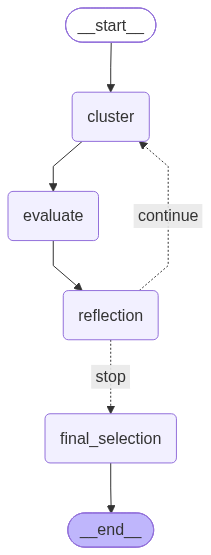

In [19]:
display(Image(graph.get_graph().draw_mermaid_png()))

In [20]:
print("Decision:", result["decision"])
print("Reason:", result["reason"])

Decision: stop
Reason: Evidence indicates an optimum around high n_neighbors and n_pcs at resolution 0.5. The configuration n_neighbors=50, n_pcs=50, resolution=0.5 yields the best silhouette (0.191) and lowest DB (1.768) among tested, with 5 coherent lineage-level clusters and only one tiny platelet cluster. Nearby settings (n_neighbors 35–40 or n_pcs 45; higher resolutions 0.55–0.9) consistently worsen separation/compactness or over-fragment. Further small adjustments are unlikely to yield meaningful improvement.


In [21]:
state.keys()

dict_keys(['messages', 'adata', 'parameters', 'metrics', 'history', 'experiment_log', 'iteration', 'decision', 'reason', 'evaluated_configs', 'clustering_time', 'evaluation_time', 'llm_decision_time', 'selected_iteration', 'best_experiment', 'final_selection_reason', 'final_selection_time'])

In [22]:
# print(type(decision))

In [23]:
for experiment in result["history"]:
    print("\nIteration:", experiment["iteration"])
    print("Parameters:", experiment["parameters"])
    print("Metrics:", experiment["metrics"])


Iteration: 0
Parameters: {'n_neighbors': 15, 'resolution': 1.0, 'n_pcs': 20}
Metrics: {'n_neighbors': 15, 'resolution': 1.0, 'n_pcs': 20, 'random_state': 42, 'n_clusters': 10, 'cluster_sizes': {'0': 574, '1': 552, '2': 347, '3': 299, '4': 164, '5': 465, '6': 168, '7': 23, '8': 32, '9': 14}, 'largest_cluster_size': 574, 'largest_cluster_fraction': 0.2175890826383624, 'number_of_small_clusters': 3, 'small_clusters': {'7': 23, '8': 32, '9': 14}, 'silhouette_score': 0.07478884607553482, 'davies_bouldin_score': 2.666380841974742, 'wc_dispersion_score': 374182.5, 'banfield_raftery_score': 12939.826171875, 'marker_genes': {'0': ['MALAT1', 'CD27', 'IL7R', 'SELL', 'LTB'], '1': ['IL32', 'LTB', 'IL7R', 'B2M', 'CD2'], '2': ['CD74', 'CD79A', 'HLA-DRA', 'CD79B', 'HLA-DPB1'], '3': ['CCL5', 'NKG7', 'GZMA', 'B2M', 'CST7'], '4': ['NKG7', 'GNLY', 'GZMB', 'CTSW', 'PRF1'], '5': ['LYZ', 'S100A9', 'S100A8', 'TYROBP', 'FTL'], '6': ['LST1', 'FCER1G', 'AIF1', 'COTL1', 'FCGR3A'], '7': ['ISG15', 'IFI6', 'MX1', '

In [24]:
# print(decision)

In [25]:
for experiment in result["history"]:
    print("\nIteration:", experiment["iteration"])
    print(
        "Parameters:",
        experiment["parameters"]
    )
    print(
        "Silhouette:",
        experiment["metrics"]["silhouette_score"]
    )
    print(
        "DBI:",
        experiment["metrics"][
            "davies_bouldin_score"
        ]
    )
    print(
        "WC-dispersion:",
        experiment["metrics"][
            "wc_dispersion_score"
        ]
    )
    print(
        "Banfield-Raftery:",
        experiment["metrics"][
            "banfield_raftery_score"
        ]
    )
    print(
        "Clusters:",
        experiment["metrics"]["n_clusters"]
    )


Iteration: 0
Parameters: {'n_neighbors': 15, 'resolution': 1.0, 'n_pcs': 20}
Silhouette: 0.07478884607553482
DBI: 2.666380841974742
WC-dispersion: 374182.5
Banfield-Raftery: 12939.826171875
Clusters: 10

Iteration: 1
Parameters: {'n_neighbors': 30, 'resolution': 0.8, 'n_pcs': 30}
Silhouette: 0.0749155730009079
DBI: 2.619893754959516
WC-dispersion: 374162.75
Banfield-Raftery: 12959.4248046875
Clusters: 9

Iteration: 2
Parameters: {'n_neighbors': 45, 'resolution': 0.6, 'n_pcs': 40}
Silhouette: 0.1683310866355896
DBI: 1.936133135108512
WC-dispersion: 392932.15625
Banfield-Raftery: 13084.486328125
Clusters: 7

Iteration: 3
Parameters: {'n_neighbors': 45, 'resolution': 0.8, 'n_pcs': 40}
Silhouette: 0.1674061119556427
DBI: 1.9427128170835102
WC-dispersion: 393241.28125
Banfield-Raftery: 13087.275390625
Clusters: 7

Iteration: 4
Parameters: {'n_neighbors': 45, 'resolution': 0.9, 'n_pcs': 50}
Silhouette: 0.07691837102174759
DBI: 2.5400419593158454
WC-dispersion: 384858.125
Banfield-Raftery: 1

This shows the LLM is:

+ reading optimization history,
+ identifying the best experiment,
+ avoiding changing multiple parameters at once

**But the LLM occasionally proposed parameter combinations that had already been evaluated**

The LLM follows a controlled optimization strategy. If some parameters are already giving good results, it leaves them unchanged and only modifies one parameter at a time. This makes it easier to see whether that specific adjustment improves the clustering.

In [26]:
best_experiment = result["history"][2]

best_params = best_experiment["parameters"]

print(best_params)

{'n_neighbors': 45, 'resolution': 0.6, 'n_pcs': 40}


In [27]:
pbmc_data_best = cl.run_clustering(
    pbmc_data.copy(),
    n_neighbors=best_params["n_neighbors"],
    resolution=best_params["resolution"],
    n_pcs=best_params["n_pcs"],)

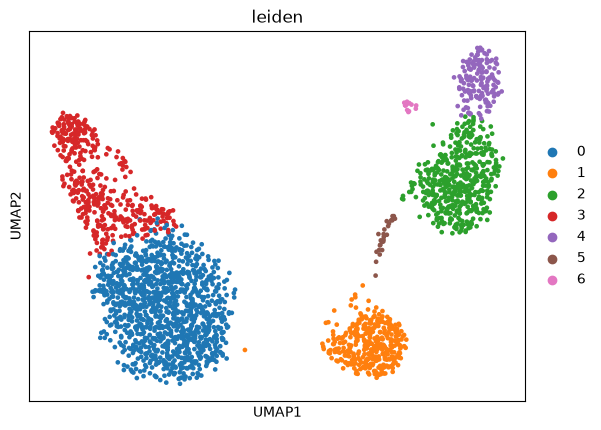

In [28]:
viz.plot_umap(pbmc_data_best, color="leiden")

In [29]:
ev.get_cluster_summary(pbmc_data_best)

{'0': 1194, '1': 347, '2': 482, '3': 420, '4': 156, '5': 26, '6': 13}

In [30]:
result["metrics"]["marker_genes"]

{'0': ['IL32', 'LTB', 'IL7R', 'MALAT1', 'CD2'],
 '1': ['CD74', 'HLA-DRA', 'HLA-DPB1', 'CD79A', 'HLA-DQA1'],
 '2': ['FTL', 'FTH1', 'TYROBP', 'LYZ', 'CST3'],
 '3': ['NKG7', 'CST7', 'GZMA', 'B2M', 'CTSW'],
 '4': ['PF4', 'SDPR', 'GNG11', 'PPBP', 'NRGN']}

In [31]:
result["history"][-1]

{'iteration': 17,
 'parameters': {'n_neighbors': 35, 'resolution': 0.5, 'n_pcs': 50},
 'metrics': {'n_neighbors': 35,
  'resolution': 0.5,
  'n_pcs': 50,
  'random_state': 42,
  'n_clusters': 5,
  'cluster_sizes': {'0': 1282, '1': 370, '2': 639, '3': 334, '4': 13},
  'largest_cluster_size': 1282,
  'largest_cluster_fraction': 0.48597422289613346,
  'number_of_small_clusters': 1,
  'small_clusters': {'4': 13},
  'silhouette_score': 0.18879598379135132,
  'davies_bouldin_score': 1.7959739000953827,
  'wc_dispersion_score': 410983.96875,
  'banfield_raftery_score': 13213.23828125,
  'marker_genes': {'0': ['IL32', 'LTB', 'IL7R', 'MALAT1', 'CD2'],
   '1': ['CD74', 'HLA-DRA', 'HLA-DPB1', 'CD79A', 'HLA-DQA1'],
   '2': ['FTL', 'FTH1', 'TYROBP', 'LYZ', 'CST3'],
   '3': ['NKG7', 'CST7', 'GZMA', 'B2M', 'CTSW'],
   '4': ['PF4', 'SDPR', 'GNG11', 'PPBP', 'NRGN']}}}

In [32]:
result["decision"]

'stop'

In [33]:
result["reason"]

'Evidence indicates an optimum around high n_neighbors and n_pcs at resolution 0.5. The configuration n_neighbors=50, n_pcs=50, resolution=0.5 yields the best silhouette (0.191) and lowest DB (1.768) among tested, with 5 coherent lineage-level clusters and only one tiny platelet cluster. Nearby settings (n_neighbors 35–40 or n_pcs 45; higher resolutions 0.55–0.9) consistently worsen separation/compactness or over-fragment. Further small adjustments are unlikely to yield meaningful improvement.'

In [ ]:
final_selection_reason=(
    final_decision.reason
)